# Chromosome, Replicate 1 Scripting

Create a script to run the deconvolution on each replicate. This notebook will test the script.


In [4]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
from pipeline.fit_replication_profiles import main
from src.utils import mkdir_safe

output_dir = "output/prototype_pipeline_subset/"


In [10]:
from src.config import load_default_chrom_configs
from src.RealDataReplication import RealDataReplicationDeconvolution
from src.optimize_H import create_bounds_params_from_config

replicate = 1
chrom = 4

config1, config2 = load_default_chrom_configs(from_CLOCCS=True)
config = config1 if replicate == 1 else config2

replication_deconvolver = RealDataReplicationDeconvolution(config, replicate=replicate, 
    chr=chrom)

subset_parameters = ['mu0', 'gamma1', 'gamma2', 'sigma0']
bounds_df = create_bounds_params_from_config(config)
bounds_df = bounds_df.loc[subset_parameters]

# Warm start load of N, B, and the config parameters
replication_deconvolver.setup_deconvolution(config, 
    warm_start_output_directory=output_dir)


Shifting mu0, gamma1, and gamma2, for alpha...
Omit windows with less than 75% read coverage.
Warm start config, N, F, and B from directory: output/prototype_pipeline_subset/
Deconvolving 702 regions
Warm start config, N, F, and B from directory: output/prototype_pipeline_subset/


In [15]:
replication_deconvolver.iterative_deconvolution_updates(5)

[0] 00:00:00.354, rn=0.003430716616844985
[1] 00:00:00.735, rn=0.0032228596026941964
[2] 00:00:01.194, rn=0.0032111834545106737
[3] 00:00:01.555, rn=0.0032055110281690195
[4] 00:00:01.895, rn=0.0032018612296716275


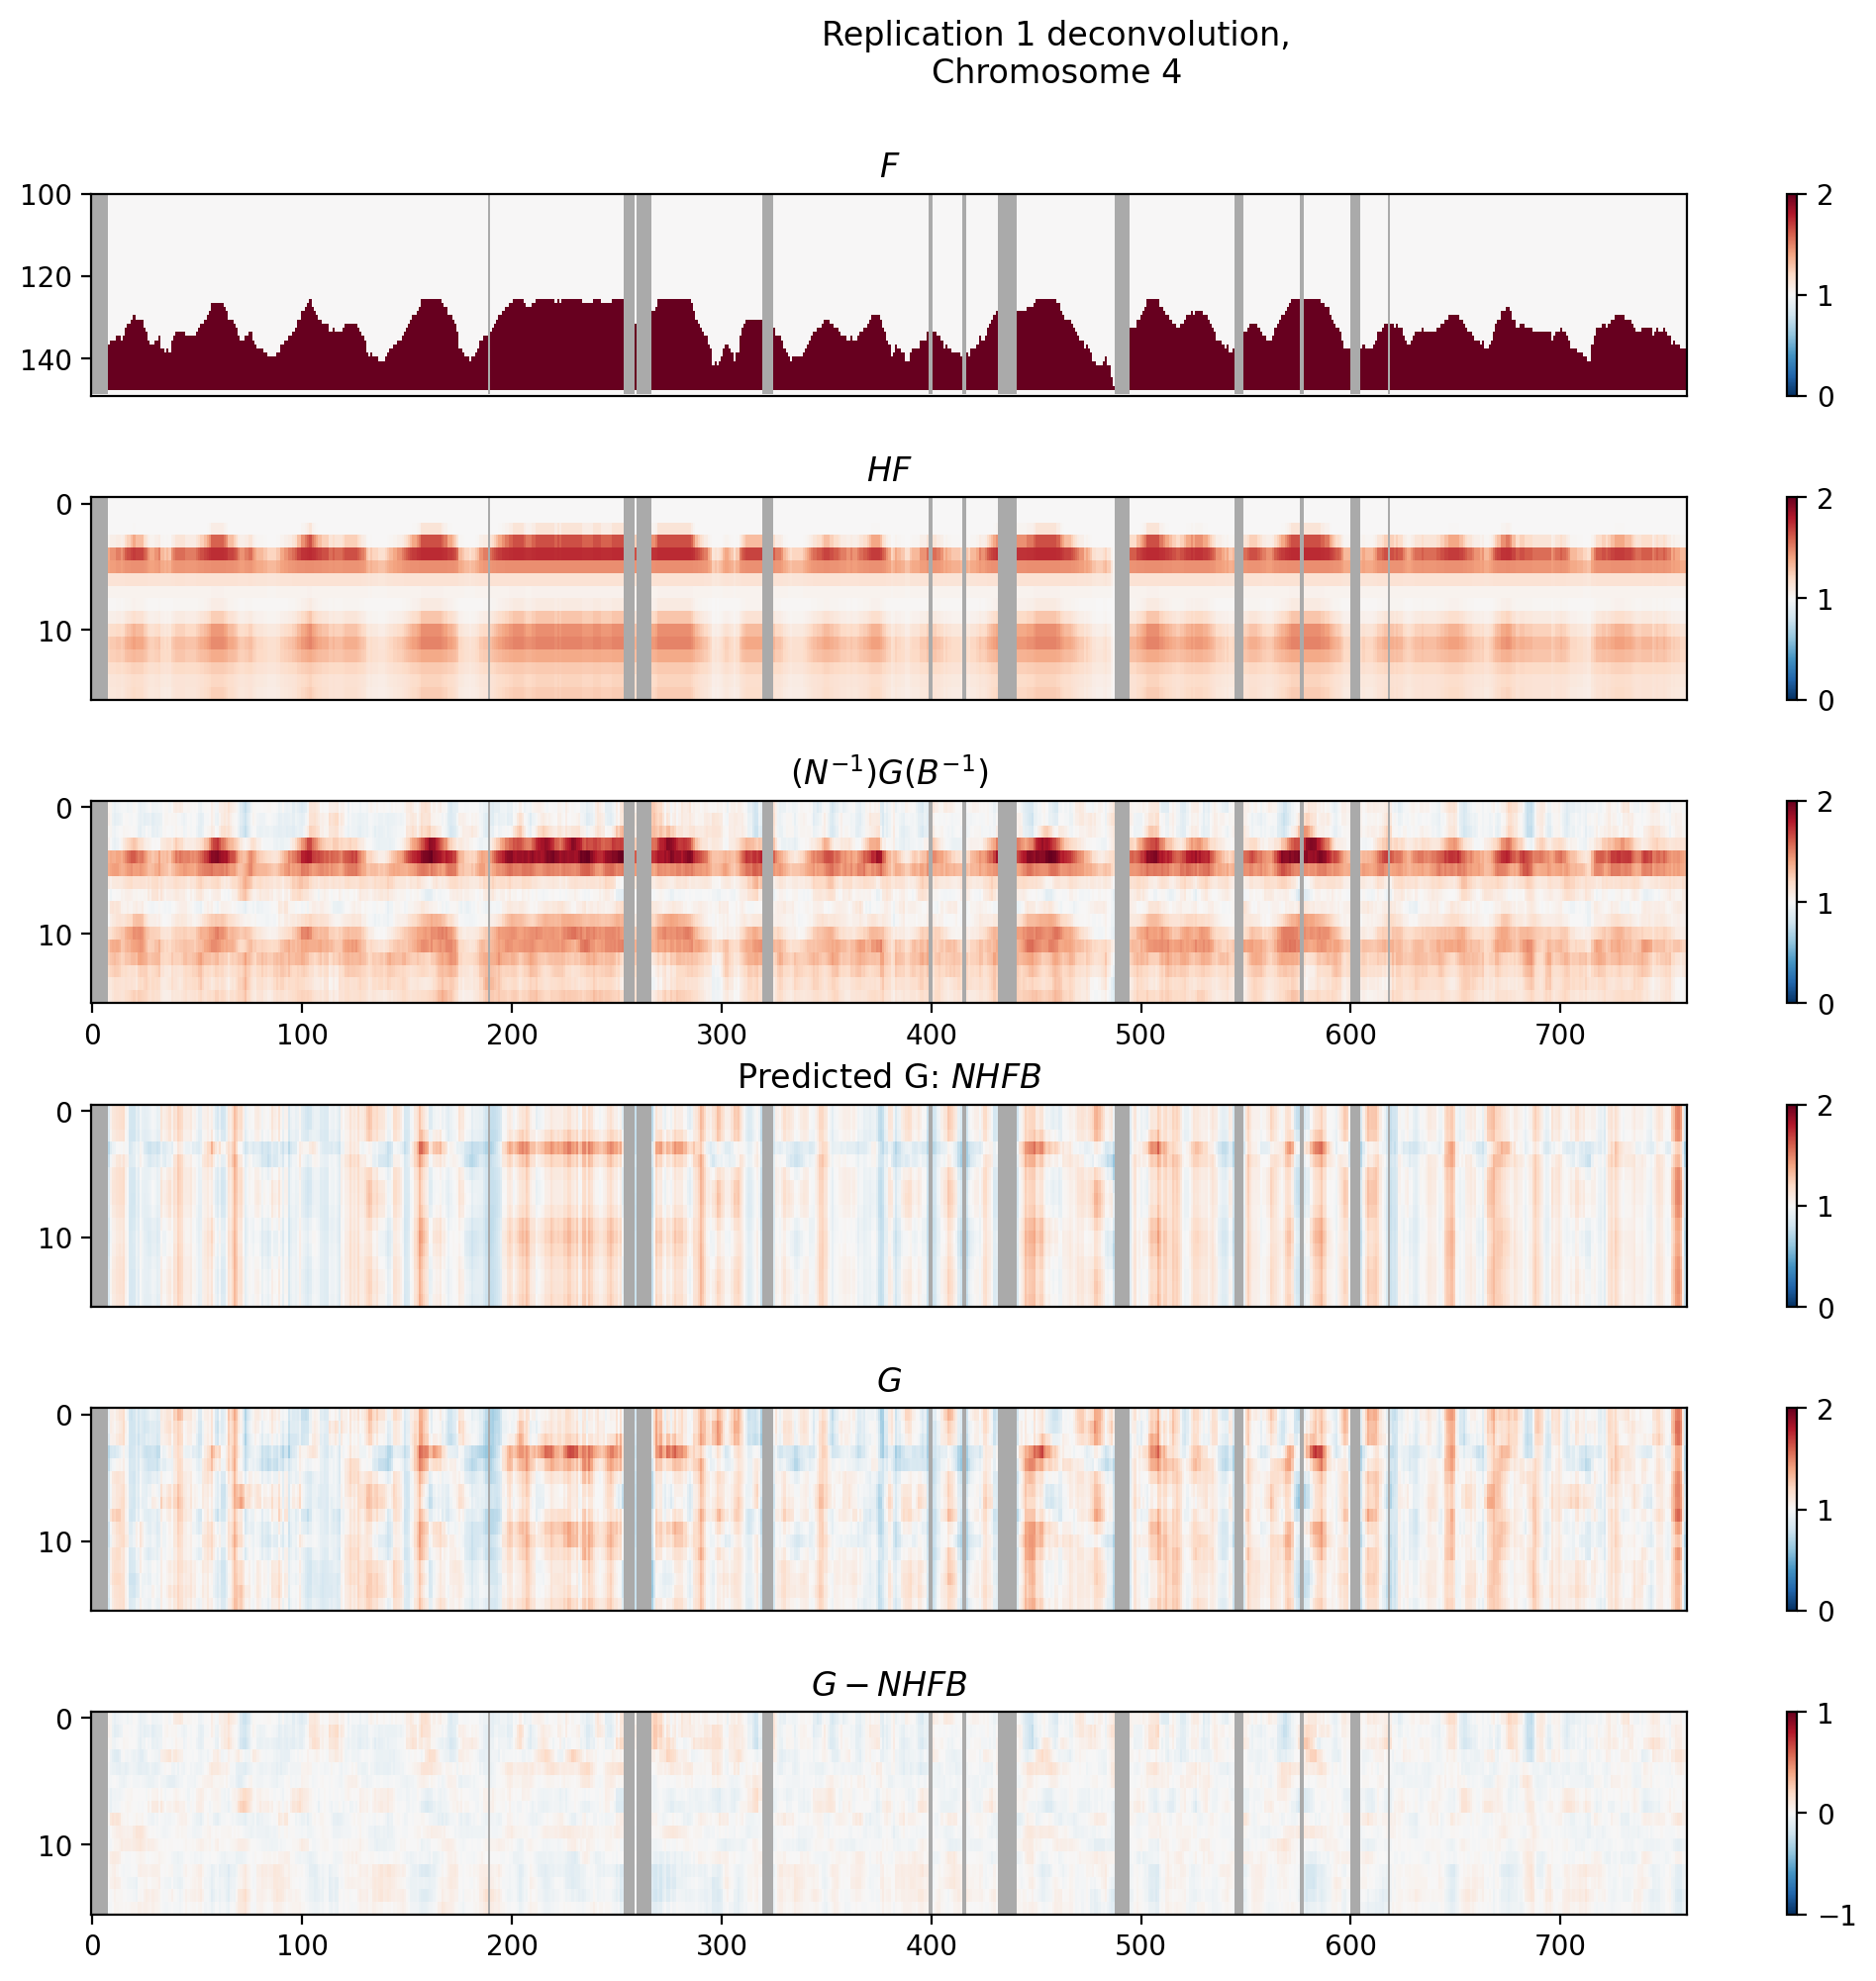

In [16]:
fig = replication_deconvolver.plot_heatmaps()

In [116]:
replicate = 1
chrom = 4
config1, config2 = load_default_chrom_configs(from_CLOCCS=True)
config = config1

replication_deconvolver = RealDataReplicationDeconvolution(config, replicate=replicate, 
    chr=chrom)

Shifting mu0, gamma1, and gamma2, for alpha...
Omit windows with less than 75% read coverage.


In [117]:
# We'll start from cold start
replication_deconvolver.setup_deconvolution(config, 
    warm_start_output_directory='output/prototype_pipeline_subset')

Warm start config, N, F, and B from directory: output/prototype_pipeline_subset
Quantile for cutoff: 0.75
Cutoff for threshold: 0.09
Number of windows to include:  526
Deconvolving 526 regions
Warm start config, N, F, and B from directory: output/prototype_pipeline_subset


In [118]:
subset_parameters = ['mu0', 'gamma1', 'gamma2', 'sigma0']
bounds_df = create_bounds_params_from_config(config)
bounds_df = bounds_df.loc[subset_parameters]

In [126]:
replication_deconvolver.iterative_deconvolution_updates(100)

[0] 00:00:00.258, rn=1.0215078591014253
[1] 00:00:00.524, rn=0.003588035690653265
[2] 00:00:00.787, rn=0.003454844451325326
[3] 00:00:01.049, rn=0.0033464929530627584
[4] 00:00:01.357, rn=0.003247437141120497
[5] 00:00:01.699, rn=0.003149225797308123
[6] 00:00:01.963, rn=0.0030599304547417393
[7] 00:00:02.233, rn=0.0029692224384876196
[8] 00:00:02.504, rn=0.0028835492481940343
[9] 00:00:02.768, rn=0.002801743259359849
[10] 00:00:03.033, rn=0.0027212534780200856
[11] 00:00:03.296, rn=0.0026503969881818525
[12] 00:00:03.563, rn=0.0025851630130240472
[13] 00:00:03.827, rn=0.0025273758188201884
[14] 00:00:04.089, rn=0.0024762271212192973
[15] 00:00:04.355, rn=0.0024386169936311355
[16] 00:00:04.616, rn=0.0024022769441322815
[17] 00:00:04.879, rn=0.0023747988994727333
[18] 00:00:05.143, rn=0.002350100946081002
[19] 00:00:05.413, rn=0.002327586765461234
[20] 00:00:05.680, rn=0.0023113167347367917
[21] 00:00:05.945, rn=0.0022998915461917716
[22] 00:00:06.208, rn=0.0022913465179172773
[23] 00:

Quantile for cutoff: 0.75
Cutoff for threshold: 0.09
Number of windows to include:  526


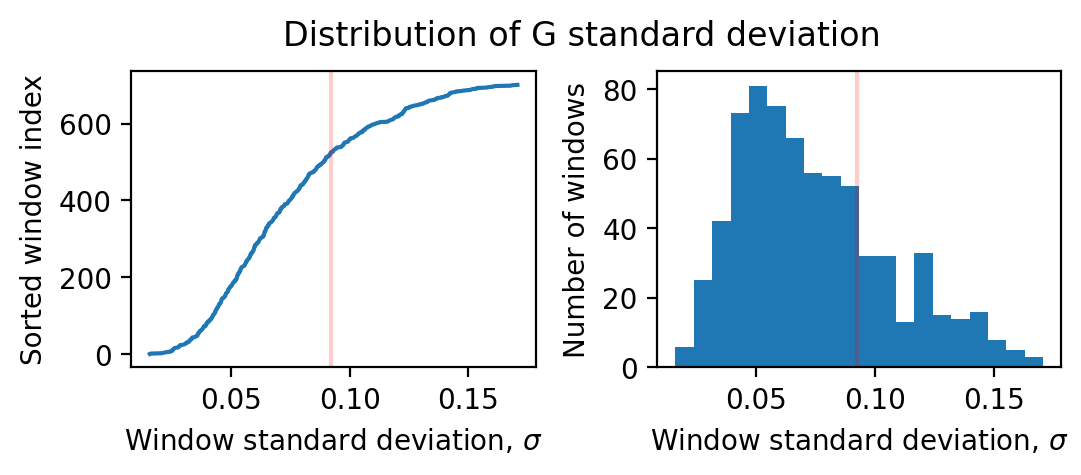

In [127]:
_ = replication_deconvolver.randomly_subset_windows_to_deconvolve(
    replication_deconvolver.masked_G_df, plot_std=True)

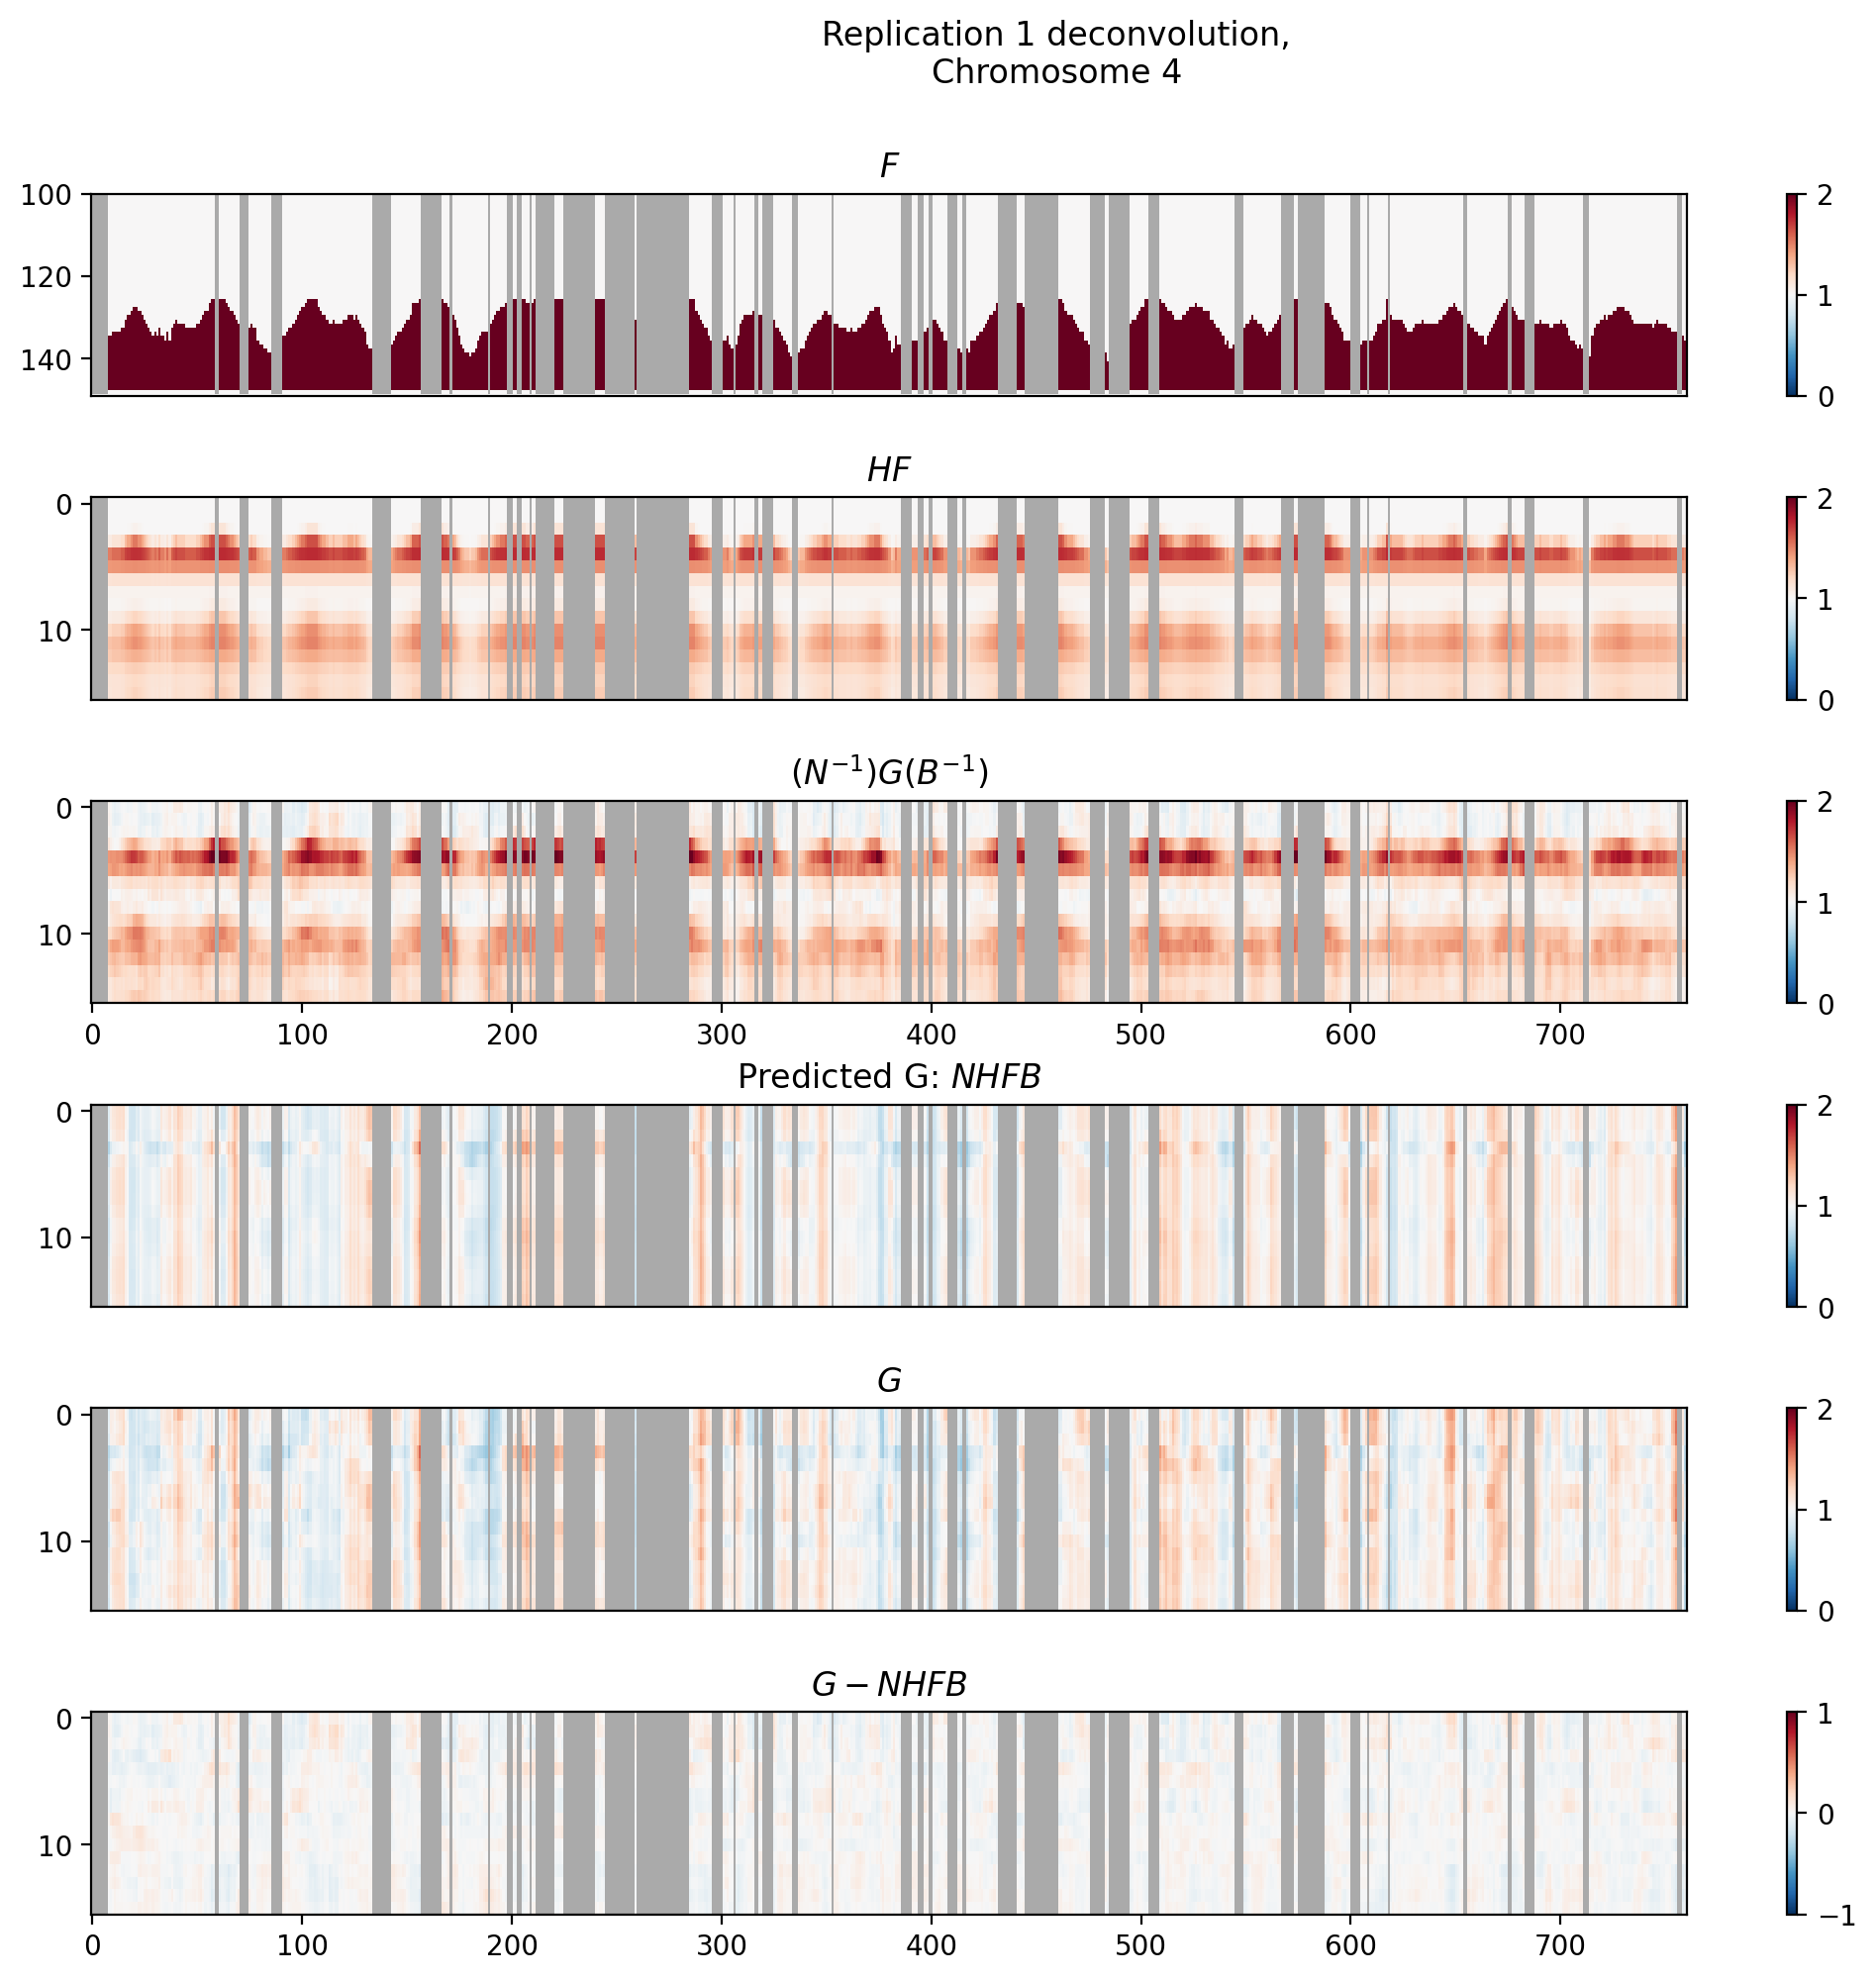

In [128]:
fig = replication_deconvolver.plot_heatmaps()